In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from datetime import datetime
import pytz
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
apps_df = pd.read_csv('Play Store Data.csv')
reviews_df = pd.read_csv('User Reviews.csv')

In [3]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
apps_df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [5]:
required_cols = ['Category', 'Rating', 'Reviews', 'Installs', 'Size', 'Last Updated']
apps_df.dropna(subset=required_cols, inplace=True)
apps_df = apps_df[apps_df[required_cols].apply(lambda col: col.astype(str).str.strip() != '').all(axis=1)]
print(f"Rows after null removal: {len(apps_df)}")

Rows after null removal: 9367


In [6]:
apps_df['Rating'] = pd.to_numeric(apps_df['Rating'], errors='coerce')
apps_df.dropna(subset=['Rating'], inplace=True)
apps_df = apps_df[apps_df['Rating'] <= 5]

In [7]:
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')
apps_df.dropna(subset=['Reviews'], inplace=True)
apps_df['Reviews'] = apps_df['Reviews'].astype(int)

In [18]:
apps_df['Installs'] = (apps_df['Installs'].astype(str).str.replace(',', '', regex=False).str.replace('+', '', regex=False).str.strip())
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce')
apps_df.dropna(subset=['Installs'], inplace=True)
apps_df['Installs'] = apps_df['Installs'].astype(int)
print("Sample Installs:", apps_df['Installs'].head().tolist())

Sample Installs: [10000, 100000, 10000, 1000000, 1000000]


In [19]:
def convert_size(size):
    size = str(size).strip()

    try:
        if size.endswith('M'):
            return float(size[:-1])
        elif size.endswith('k'):
            return float(size[:-1]) / 1024
    except:
        pass

    return np.nan

apps_df['Size'] = apps_df['Size'].apply(convert_size)
apps_df.dropna(subset=['Size'], inplace=True)

print(f"Rows after Size cleaning: {len(apps_df)}")

Rows after Size cleaning: 0


In [10]:
apps_df['Last Updated'] = pd.to_datetime(apps_df['Last Updated'], errors='coerce')
apps_df.dropna(subset=['Last Updated'], inplace=True)
apps_df = apps_df[apps_df['Last Updated'].dt.month == 1]
print(f"Rows after January filter: {len(apps_df)}")

Rows after January filter: 368


In [11]:
apps_df = apps_df[apps_df['Rating'] >= 4.0]
print(f"After Rating filter (>=4.0): {len(apps_df)}")

After Rating filter (>=4.0): 271


In [12]:
apps_df = apps_df[apps_df['Size'] > 10]
print(f"After Size filter (>10 MB): {len(apps_df)}")

After Size filter (>10 MB): 131


In [13]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
33,Easy Origami Ideas,ART_AND_DESIGN,4.2,1015,11.0,100000,Free,0,Everyone,Art & Design,2018-01-06,1.1.0,4.1 and up
44,Popsicle Sticks and Similar DIY Craft Ideas,ART_AND_DESIGN,4.2,26,12.0,10000,Free,0,Everyone,Art & Design,2018-01-03,1.0.0,4.1 and up
446,Video Caller Id,COMMUNICATION,4.2,15287,17.0,1000000,Free,0,Everyone,Communication,2018-01-24,2.2.245,4.0.3 and up
719,Monster Truck Driver & Racing,EDUCATION,4.4,748,51.0,1000000,Free,0,Everyone,Education;Action & Adventure,2017-01-19,1.0.9,2.3 and up


In [14]:
if apps_df.empty:
    print("No data available for the selected filtering criteria.")
else:
    category_agg = apps_df.groupby('Category').agg(
        Avg_Rating=('Rating', 'mean'),
        Total_Reviews=('Reviews', 'sum'),
        Total_Installs=('Installs', 'sum')
    ).reset_index()

    # Top 10 by Total Installs
    top10 = category_agg.sort_values('Total_Installs', ascending=False).head(10)
    top10 = top10.reset_index(drop=True)
    print(top10)

          Category  Avg_Rating  Total_Reviews  Total_Installs
0           FAMILY    4.395455        4544623       182494820
1           SPORTS    4.342857        1982017       120511000
2             GAME    4.313333        2397589       115691000
3    ENTERTAINMENT    4.250000        1238948        51000000
4  PERSONALIZATION    4.475000         155996        15060000
5      PHOTOGRAPHY    4.150000         563720        10500000
6        LIFESTYLE    4.380000          42809         5071000
7        EDUCATION    4.400000          57645         2000000
8         SHOPPING    4.200000          19950         2000000
9            TOOLS    4.200000           8010         1010000


In [15]:
ist = pytz.timezone('Asia/Kolkata')
now_ist = datetime.now(ist)
hour_ist = now_ist.hour
minute_ist = now_ist.minute

# Convert to decimal hours for easy comparison
current_decimal = hour_ist + minute_ist / 60
window_start = 15.0   # 3:00 PM
window_end   = 17.0   # 5:00 PM

in_window = window_start <= current_decimal <= window_end
print(f"Current IST: {now_ist.strftime('%I:%M %p')} | Chart visible: {in_window}")

Current IST: 04:44 PM | Chart visible: True


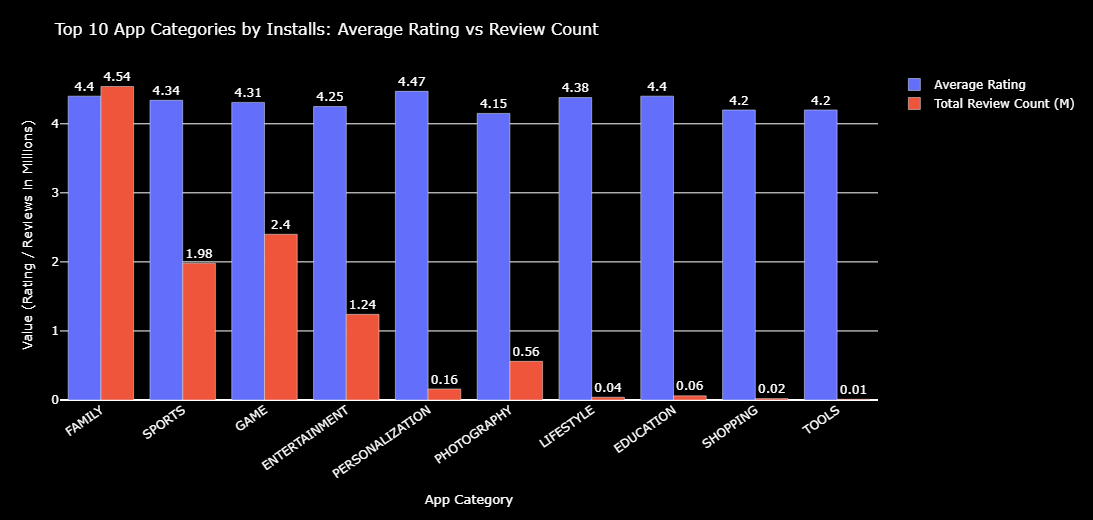

Chart saved: grouped_bar_chart.html


In [16]:
html_output_path = "./"
os.makedirs(html_output_path, exist_ok=True)

if apps_df.empty:
    chart_html = "<p style='color:white;text-align:center;padding:40px;'>No data available for the selected filtering criteria.</p>"

elif not in_window:
    chart_html = ""  # No placeholder — completely hidden outside window

else:
    fig = go.Figure()

    # Bar 1 — Average Rating
    fig.add_trace(go.Bar(
        name='Average Rating',
        x=top10['Category'],
        y=top10['Avg_Rating'].round(2),
        marker_color='#636EFA',
        text=top10['Avg_Rating'].round(2),
        textposition='outside'
    ))

    # Bar 2 — Total Review Count (scaled to millions for readability)
    fig.add_trace(go.Bar(
        name='Total Review Count (M)',
        x=top10['Category'],
        y=(top10['Total_Reviews'] / 1e6).round(2),
        marker_color='#EF553B',
        text=(top10['Total_Reviews'] / 1e6).round(2),
        textposition='outside'
    ))

    fig.update_layout(
        barmode='group',
        title=dict(
            text='Top 10 App Categories by Installs: Average Rating vs Review Count',
            font=dict(size=16, color='white')
        ),
        xaxis=dict(
            title='App Category',
            title_font=dict(size=13, color='white'),
            tickfont=dict(color='white'),
            tickangle=-35
        ),
        yaxis=dict(
            title='Value (Rating / Reviews in Millions)',
            title_font=dict(size=13, color='white'),
            tickfont=dict(color='white')
        ),
        legend=dict(font=dict(color='white'), bgcolor='rgba(0,0,0,0)'),
        plot_bgcolor='black',
        paper_bgcolor='black',
        font_color='white',
        margin=dict(l=60, r=30, t=70, b=120),
        width=950,
        height=520
    )

    chart_html = pio.to_html(fig, full_html=False, include_plotlyjs='inline')
    fig.write_html(os.path.join(html_output_path, 'grouped_bar_chart.html'), full_html=False, include_plotlyjs='inline')
    fig.show()
    print("Chart saved: grouped_bar_chart.html")

In [17]:
dashboard_html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Play Store Dashboard</title>
    <style>
        body {{ background: #0d0d0d; color: white; font-family: 'Segoe UI', sans-serif; margin: 0; padding: 20px; }}
        h1 {{ text-align: center; color: #a78bfa; margin-bottom: 8px; }}
        .subtitle {{ text-align: center; color: #9ca3af; font-size: 13px; margin-bottom: 30px; }}
        .chart-wrapper {{ display: {'block' if in_window and not apps_df.empty else 'none'}; }}
        .no-data {{ text-align: center; padding: 50px; color: #ef4444; font-size: 15px; display: {'block' if apps_df.empty else 'none'}; }}
        .time-notice {{ text-align:center; padding: 30px; color: #f59e0b; font-size: 14px; display: {'block' if not in_window else 'none'}; }}
    </style>
</head>
<body>
    <h1>Play Store Analytics Dashboard</h1>
    <div class="subtitle">Filtered: January Updates | Rating ≥ 4.0 | Size > 10 MB | Top 10 Categories by Installs</div>

    <div class="no-data">No data available for the selected filtering criteria.</div>

    <div class="time-notice">
        ⏰ Chart is only available between <strong>3:00 PM – 5:00 PM IST</strong>.<br>
        Current IST: <strong>{now_ist.strftime('%I:%M %p')}</strong>
    </div>

    <div class="chart-wrapper">
        {chart_html}
    </div>
</body>
</html>
"""

dashboard_path = os.path.join(html_output_path, 'dashboard.html')
with open(dashboard_path, 'w', encoding='utf-8') as f:
    f.write(dashboard_html)

print(f"Dashboard saved: {dashboard_path}")
print(f"IST Time: {now_ist.strftime('%I:%M %p')} | Window active: {in_window}")

Dashboard saved: ./dashboard.html
IST Time: 04:44 PM | Window active: True
